In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc)

### LOAD DATA

In [15]:
df = pd.read_csv(r"..\data\churn_boosting.csv")

print("=" * 55)
print("TELCO CUSTOMER CHURN – BOOSTING MODELS")
print("=" * 55)
print("\n── Dataset Info ──")
print(df.head())
print(df.describe())
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

TELCO CUSTOMER CHURN – BOOSTING MODELS

── Dataset Info ──
   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0
           Tenure  MonthlyCharges       Churn
count  120.000000      120.000000  120.000000
mean    35.300000       62.647583    0.058333
std     20.564553       27.050088    0.235355
min      1.000000       21.450000    0.000000
25%     18.000000       38.385000    0.000000
50%     34.500000       58.475000    0.000000
75%     54.000000       82.355000    0.000000
max     71.000000      118.650000    1.000000
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 

### PRE-PROCESSING

In [16]:

# Drop rows where InternetService is missing (43 rows)
df.dropna(subset=['InternetService'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df['ContractType']     = le.fit_transform(df['ContractType'])      # ordinal-ish
df['InternetService']  = le.fit_transform(df['InternetService'])

# Features and target
X = df[['Tenure', 'MonthlyCharges', 'ContractType']]
y = df['Churn']

print(f"\nSamples after cleaning : {len(df)}")
print(f"Churn distribution     :\n{y.value_counts()}")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Samples after cleaning : 77
Churn distribution     :
Churn
0    74
1     3
Name: count, dtype: int64


### TRAIN MODELS

In [17]:

# --- AdaBoost ---
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5,
                        random_state=42)
ada.fit(X_train, y_train)
y_pred_ada  = ada.predict(X_test)
y_prob_ada  = ada.predict_proba(X_test)[:, 1]

# --- Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb   = gb.predict(X_test)
y_prob_gb   = gb.predict_proba(X_test)[:, 1]

### PERFORMANCE COMPARISON

In [18]:

print("\n" + "=" * 55)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 55)

for name, y_pred, y_prob in [
    ("AdaBoost",          y_pred_ada, y_prob_ada),
    ("Gradient Boosting", y_pred_gb,  y_prob_gb),
]:
    print(f"\n── {name} ──")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=["No Churn", "Churn"]))


MODEL PERFORMANCE COMPARISON

── AdaBoost ──
  Accuracy  : 0.9375
              precision    recall  f1-score   support

    No Churn       0.94      1.00      0.97        15
       Churn       0.00      0.00      0.00         1

    accuracy                           0.94        16
   macro avg       0.47      0.50      0.48        16
weighted avg       0.88      0.94      0.91        16


── Gradient Boosting ──
  Accuracy  : 1.0000
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        15
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



### VISUALISATIONS

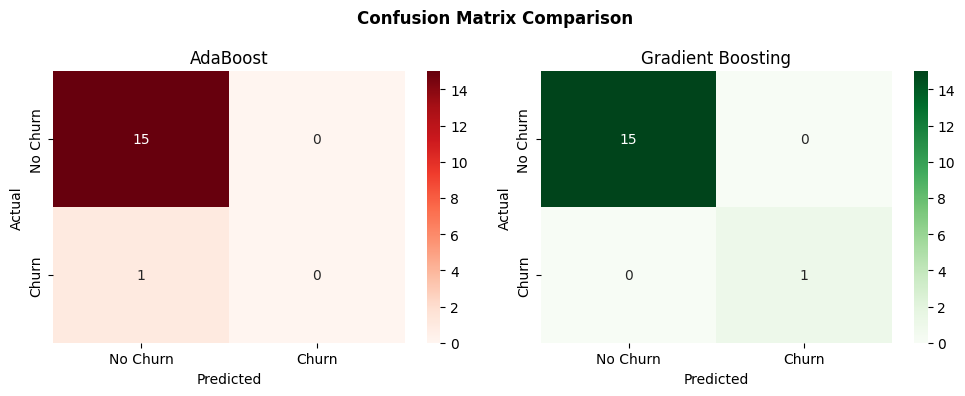

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Confusion Matrix Comparison", fontweight='bold')

for (name, y_pred, ax) in [
    ("AdaBoost", y_pred_ada, axes[0]),
    ("Gradient Boosting", y_pred_gb, axes[1])
]:
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Reds" if name == "AdaBoost" else "Greens",
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"],
                ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

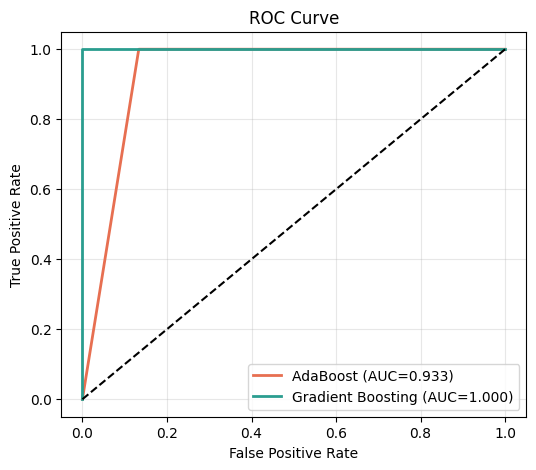

In [21]:
plt.figure(figsize=(6, 5))

for name, y_prob in [
    ("AdaBoost", y_prob_ada),
    ("Gradient Boosting", y_prob_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{name} (AUC={roc_auc:.3f})",
             color=colors[name],
             lw=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

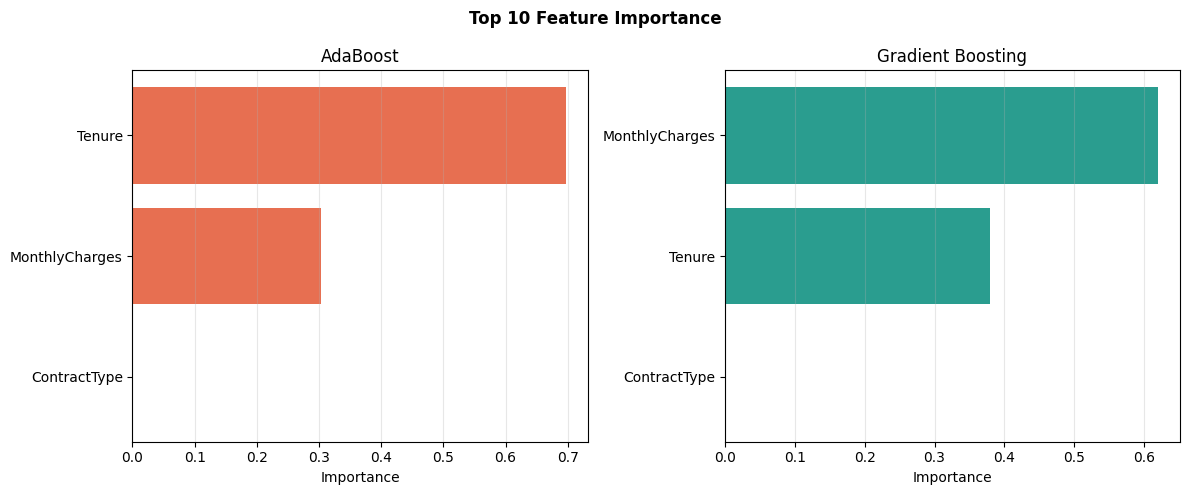

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Top 10 Feature Importance", fontweight='bold')

for name, model, ax in [
    ("AdaBoost", ada, axes[0]),
    ("Gradient Boosting", gb, axes[1])
]:
    importances = model.feature_importances_

    idx = np.argsort(importances)[-10:]
    sorted_idx = idx[np.argsort(importances[idx])]

    ax.barh([feature_names[i] for i in sorted_idx],
            importances[sorted_idx],
            color=colors[name])

    ax.set_title(name)
    ax.set_xlabel("Importance")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()